In [5]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 81.7 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 505.5/505.5 kB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.4/345.4 kB 32.1 MB/s eta 0:00:00


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from time import time
# from lib.Co_withExclusion import simulation, mul_sim_last
from numba import njit
from typing import Tuple
from scipy.optimize import curve_fit
import pickle
from binding import line_sim as new_simulation

ImportError: cannot import name 'line_sim' from 'binding' (/home/chris/Desktop/FLORIAN/binding.cpython-311-x86_64-linux-gnu.so)

In [2]:
@njit
def new_simulation(L: int, T: float, kon: float, koff: float, kstep: float, kq: float, q: float) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    # grid_kinesins = np.zeros(L) # If there is a kinesin on that side.
    # grid_sides = np.zeros(L) # If side is activated or not.

    propensities = np.zeros(4*L)
    propensities[:L] = kon
    propensities[0]=0
    propensities[L]=0
    propensities[2*L]=0
    propensities[3*L]=0
    propensities[L-1]=0
    propensities[2*L-1]=koff
    propensities[3*L-1]=0
    propensities[4*L-1]=0

    theo_dt =  (1 / L*(q*kon+koff+kstep+kq))* np.log(1.01)
    theo_iter = int(T/theo_dt)
    res = np.zeros(theo_iter)
    dts = np.zeros(theo_iter)

    period = 0.1
    blocks = int(T / period)

    i = 0
    t = 0
    block = 0
    next_write_time = period
    DATA = np.zeros((blocks, L))
    TIMES = np.zeros(blocks)

    # print(DATA.shape)
    while t<T:

        S = np.cumsum(propensities)
        r1 = np.random.uniform()
        r2 = S[-1]*np.random.random()

        dt = (1 / S[-1]) * np.log(1 / r1)
        index = np.searchsorted(S, r2, side='right')
        action = index//L
        side = index%L

        if action==0:
            propensities[side] = 0
            propensities[L + side] = koff
            propensities[2*L + side-1] = 0
            propensities[2*L + side] = (1 - propensities[L + side + 1]/koff)* kstep 
            propensities[3*L + side] = 0


        elif action==1:
            propensities[side] = q*kon
            propensities[L + side] = 0
            propensities[2*L + side] = 0
            propensities[2*L + side -1] = kstep* (propensities[L + side -1])/koff
            propensities[3*L + side] = kq


        elif action==2:
            propensities[side] = q*kon
            propensities[side+1] = 0
            propensities[L + side] = 0 
            propensities[L + side + 1] = koff 
            propensities[2*L + side - 1] = kstep* (propensities[L + side -1])/koff
            propensities[2*L + side] = 0
            propensities[2*L + side + 1] = (1 - propensities[L + side + 2]/koff)* kstep 
            propensities[3*L + side] = kq
            propensities[3*L + side+1] = 0

        else:
            propensities[side] = kon
            propensities[3*L + side] = 0
        
        propensities[0]=0
        propensities[L]=0
        propensities[2*L]=0
        propensities[3*L]=0
        propensities[L-1]=0
        propensities[2*L-1]=koff
        propensities[3*L-1]=0
        propensities[4*L-1]=0
        
        
        if next_write_time < t:
            DATA[block, :] = (propensities[:L]==0)
            TIMES[block] = t
            block += 1
            next_write_time += period

        

        if i==theo_iter:
            new_elements = np.zeros(int(theo_iter*(T/t)))
            res = np.concatenate((res, new_elements))
            dts = np.concatenate((dts, new_elements))

        res[i] = action
        dts[i] = dt
        t+=dt
     
        i+=1

    return DATA[:block], TIMES[:block], res[:i], dts[:i]
        

In [3]:
q=1

L = 300
T = 100
kon = 1
koff = 1
kstep = 100
kq = 10

In [4]:
def exponential_func(x, a, b):
    return a * np.exp(-b * x)

def get_binding_data(res, dt):
    dt_sum = np.cumsum(dt)
    a=np.where(res==0)[0]
    Dt = dt_sum[a]
    Diff = Dt[1:]-Dt[:-1]
    return Diff

def get_stepping_data(res, dt):
    dt_sum = np.cumsum(dt)
    a=np.where(res==2)[0]
    Dt = dt_sum[a]
    Diff = Dt[1:]-Dt[:-1]
    return Diff

def fit (res, dt, func):   
    hist, bins = np.histogram(func(res, dt), bins=1000, density=True) 
    bin_centers = (bins[:-1] + bins[1:]) / 2
    params, covariance = curve_fit(exponential_func, bin_centers, hist)
    return params[1]


In [5]:
#Warm up
data, times, res, dt = new_simulation(10,2, kon, koff, kstep, kq, q)

In [7]:
start = time()
data, times, res, dt = new_simulation(L, T, kon, koff, kstep, kq, 10)
print(time()-start)

0.472994327545166


In [8]:
Q = [8,3,1]
# lamda = [0,0,0,0]

fig, ax = plt.subplots(1,1)

for i, q in enumerate(Q):
    data, times, res, dt = new_simulation(L,T, kon, koff, kstep, kq, q)

    data = np.array(data)
    times = np.array(times)
    res = np.array(res)
    dt = np.array(dt)
    Diff = get_binding_data(res, dt)
    counts, bin_edges = np.histogram(Diff, bins=100, density=True)
    cdf = np.cumsum(counts)
    ax.plot(bin_edges[1:], cdf, label=f"q={q}")

    ax.set( ylim = [0,30000],xlabel="dt", ylabel="Counts", title="CDF of binding process")
    ax.legend()
    ax.grid()

: 

In [13]:
fig.savefig("cdf_dist.png")

In [15]:
Q = np.arange(1, 11)
lamda = np.zeros(10)

for q in Q:
    data, times, res, dt = new_simulation(L,T, kon, koff, kstep, kq, q)
    data = np.array(data)
    time = np.array(times)
    res = np.array(res)
    dt = np.array(dt)
    lamda[q-1] = fit(res, dt, get_binding_data)



The time between two binding events obeys the following distribution.
$P(dt) = \lambda e ^{-\lambda \cdot dt}$

Here 
$\lambda = \lambda(q)$

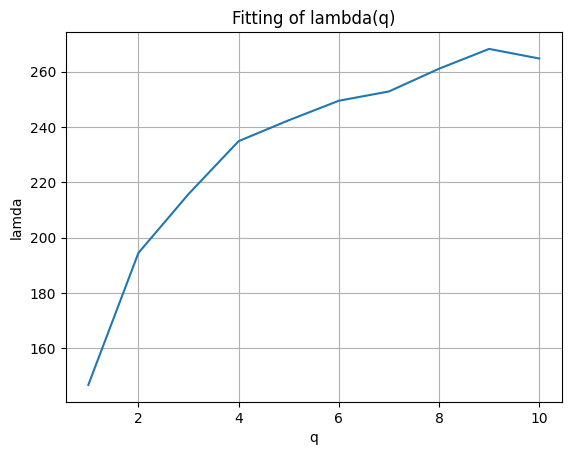

In [16]:
fig, ax = plt.subplots(1,1)
ax.plot(Q, lamda)
ax.set(xlabel = "q", ylabel = "lamda", title = "Fitting of lambda(q)")
ax.grid()

In [351]:
# fig.savefig("fitting.png", dpi=300)

In [17]:
data, times, res, dt = new_simulation(L,T, kon, koff, kstep, kq, q)

In [21]:
np.mean(np.sum(data[200:, :], axis=1))

268.49812265331667

In [44]:
N=50
Q = np.linspace(1.5,10,N)
print(Q)
lamda = np.zeros(N)
num_kins = np.zeros(N)

for i,q in enumerate(Q):
    data, times, res, dt = new_simulation(L,T, kon, koff, kstep, kq, q)
    data = np.array(data)
    time = np.array(times)
    res = np.array(res)
    dt = np.array(dt)
    num_kins[i] = np.mean(np.sum(data[200:, :], axis=1))
    lamda[i] = fit(res, dt, get_stepping_data)


[ 1.5         1.67346939  1.84693878  2.02040816  2.19387755  2.36734694
  2.54081633  2.71428571  2.8877551   3.06122449  3.23469388  3.40816327
  3.58163265  3.75510204  3.92857143  4.10204082  4.2755102   4.44897959
  4.62244898  4.79591837  4.96938776  5.14285714  5.31632653  5.48979592
  5.66326531  5.83673469  6.01020408  6.18367347  6.35714286  6.53061224
  6.70408163  6.87755102  7.05102041  7.2244898   7.39795918  7.57142857
  7.74489796  7.91836735  8.09183673  8.26530612  8.43877551  8.6122449
  8.78571429  8.95918367  9.13265306  9.30612245  9.47959184  9.65306122
  9.82653061 10.        ]


In [35]:
master_kins = num_kins.copy()
master_lamda = lamda.copy()

In [42]:
data, times, res, dt = new_simulation(L,T, kon, koff, kstep, kq, 1)

In [43]:
new_point =np.mean(np.sum(data[200:, :], axis=1))

In [63]:
# with open("line_res", "wb") as f:
#     pickle.dump({"Q":Q, "num_kins":num_kins, "lamda":lamda}, f)

In [14]:
with open("line_res", "rb") as f:
    my_dict = pickle.load(f)

Q = my_dict["Q"]
num_kins = my_dict["num_kins"]
lamda = my_dict["lamda"]

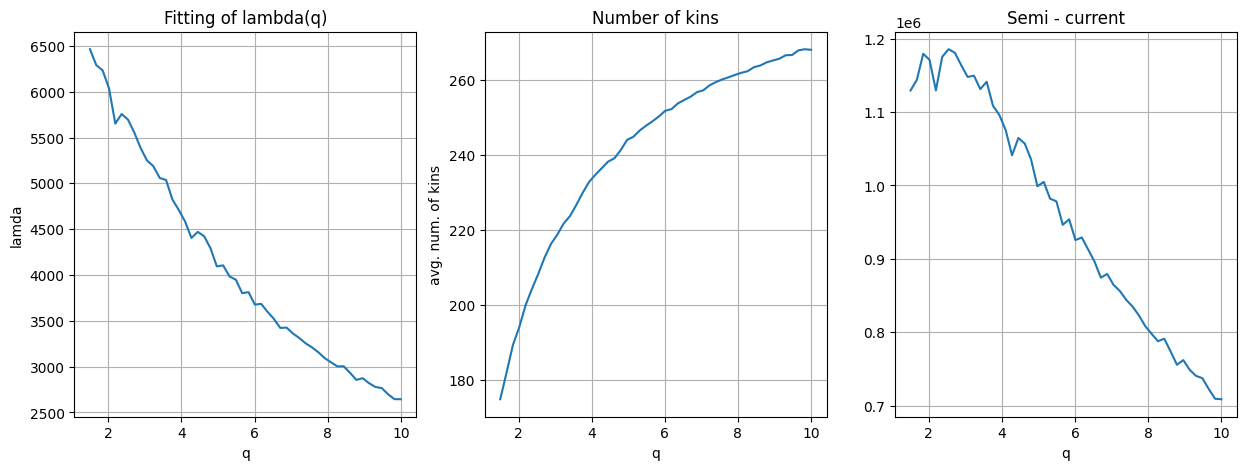

In [45]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(15,5))

ax1.plot(Q, lamda)
ax1.set(xlabel = "q", ylabel = "lamda", title = "Fitting of lambda(q)")
ax1.grid()

ax2.plot(Q, num_kins)
ax2.set(xlabel = "q", ylabel = "avg. num. of kins", title = "Number of kins")
ax2.grid()


ax3.plot(Q, num_kins*lamda)
ax3.set(xlabel = "q", ylabel = "", title = "Semi - current")
ax3.grid()

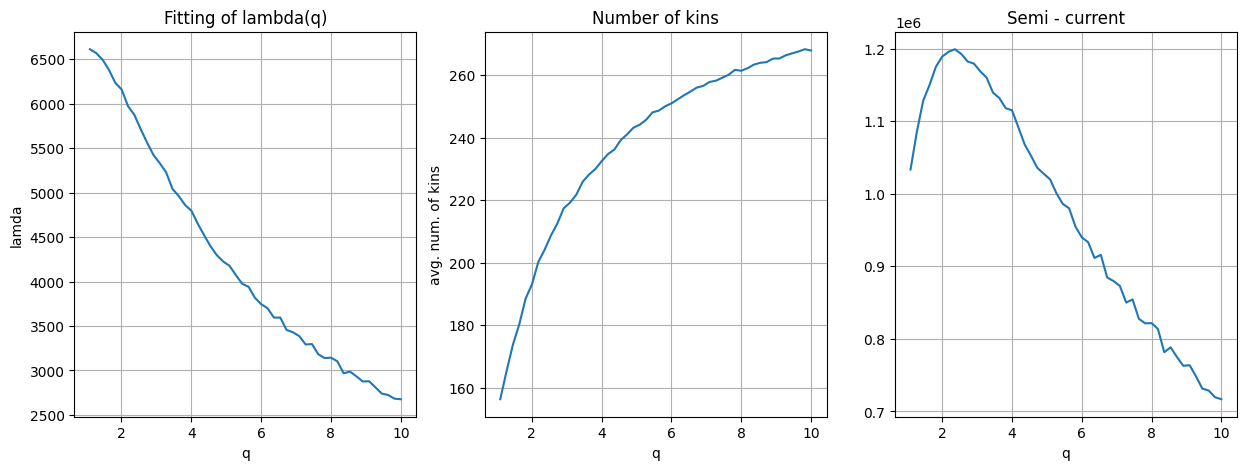

In [15]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(15,5))

ax1.plot(Q, lamda)
ax1.set(xlabel = "q", ylabel = "lamda", title = "Fitting of lambda(q)")
ax1.grid()

ax2.plot(Q, num_kins)
ax2.set(xlabel = "q", ylabel = "avg. num. of kins", title = "Number of kins")
ax2.grid()


ax3.plot(Q, num_kins*lamda)
ax3.set(xlabel = "q", ylabel = "", title = "Semi - current")
ax3.grid()

In [17]:
fig.savefig("current.png" ,dpi=300)

In [55]:
N=200
Q = np.linspace(1.1,10,N)
print(Q)
lamda = np.zeros(N)
num_kins = np.zeros(N)

for i,q in enumerate(Q):
    data, times, res, dt = new_simulation(L,T, kon, koff, 10, kq, q)
    data = np.array(data)
    time = np.array(times)
    res = np.array(res)
    dt = np.array(dt)
    num_kins[i] = np.mean(np.sum(data[200:, :], axis=1))
    lamda[i] = fit(res, dt, get_stepping_data)
    

[ 1.1         1.14472362  1.18944724  1.23417085  1.27889447  1.32361809
  1.36834171  1.41306533  1.45778894  1.50251256  1.54723618  1.5919598
  1.63668342  1.68140704  1.72613065  1.77085427  1.81557789  1.86030151
  1.90502513  1.94974874  1.99447236  2.03919598  2.0839196   2.12864322
  2.17336683  2.21809045  2.26281407  2.30753769  2.35226131  2.39698492
  2.44170854  2.48643216  2.53115578  2.5758794   2.62060302  2.66532663
  2.71005025  2.75477387  2.79949749  2.84422111  2.88894472  2.93366834
  2.97839196  3.02311558  3.0678392   3.11256281  3.15728643  3.20201005
  3.24673367  3.29145729  3.3361809   3.38090452  3.42562814  3.47035176
  3.51507538  3.55979899  3.60452261  3.64924623  3.69396985  3.73869347
  3.78341709  3.8281407   3.87286432  3.91758794  3.96231156  4.00703518
  4.05175879  4.09648241  4.14120603  4.18592965  4.23065327  4.27537688
  4.3201005   4.36482412  4.40954774  4.45427136  4.49899497  4.54371859
  4.58844221  4.63316583  4.67788945  4.72261307  4.

In [49]:
current = num_kins*lamda
M = np.max(current)
# M.index(current)

AttributeError: 'numpy.float64' object has no attribute 'index'

In [51]:
idx = np.where(current==M)[0][0]

In [52]:
Q[idx]

2.7346938775510203

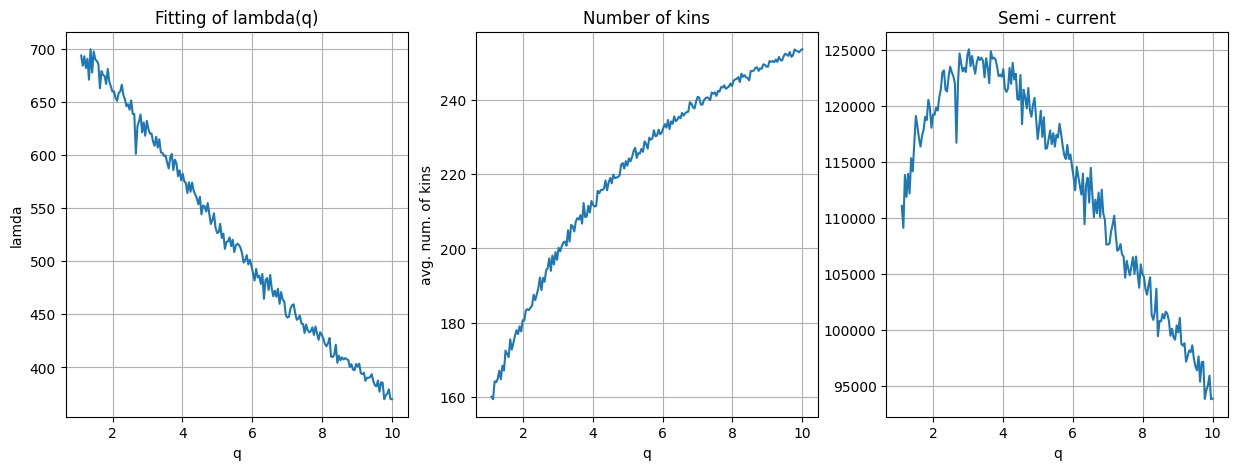

In [56]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(15,5))

ax1.plot(Q, lamda)
ax1.set(xlabel = "q", ylabel = "lamda", title = "Fitting of lambda(q)")
ax1.grid()

ax2.plot(Q, num_kins)
ax2.set(xlabel = "q", ylabel = "avg. num. of kins", title = "Number of kins")
ax2.grid()


ax3.plot(Q, num_kins*lamda)
ax3.set(xlabel = "q", ylabel = "", title = "Semi - current")
ax3.grid()

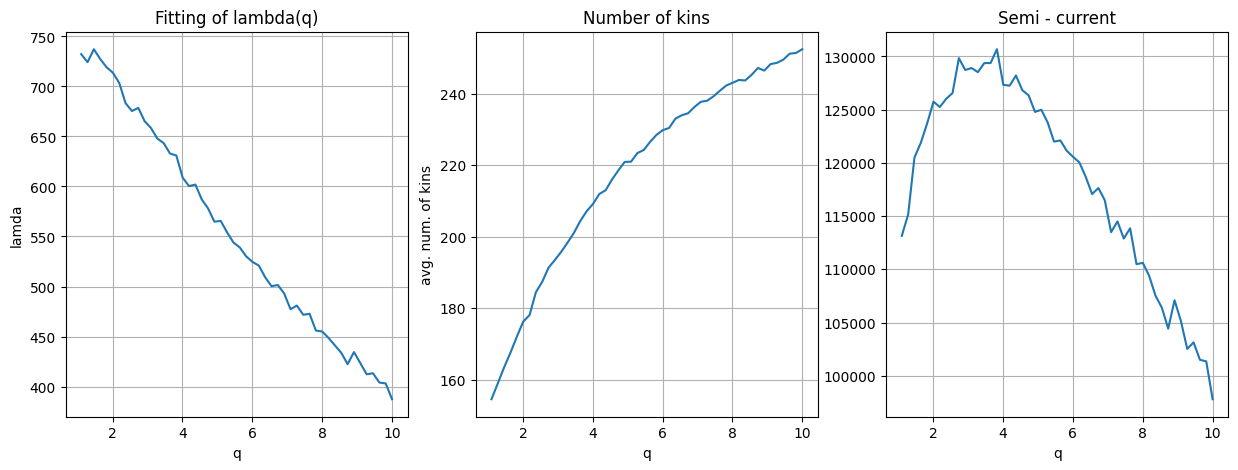

In [19]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(15,5))

ax1.plot(Q, lamda)
ax1.set(xlabel = "q", ylabel = "lamda", title = "Fitting of lambda(q)")
ax1.grid()

ax2.plot(Q, num_kins)
ax2.set(xlabel = "q", ylabel = "avg. num. of kins", title = "Number of kins")
ax2.grid()


ax3.plot(Q, num_kins*lamda)
ax3.set(xlabel = "q", ylabel = "", title = "Semi - current")
ax3.grid()


In [20]:
fig.savefig("current_10.png" ,dpi=300)

In [23]:
N=50
Q = np.linspace(1.1,10,N)
print(Q)
lamda = np.zeros(N)
num_kins = np.zeros(N)

for i,q in enumerate(Q):
    data, times, res, dt = new_simulation(L,T, kon, koff, 5, kq, q)
    num_kins[i] = np.mean(np.sum(data[200:, :], axis=1))
    lamda[i] = fit(res, dt, get_stepping_data)

[ 1.1         1.28163265  1.46326531  1.64489796  1.82653061  2.00816327
  2.18979592  2.37142857  2.55306122  2.73469388  2.91632653  3.09795918
  3.27959184  3.46122449  3.64285714  3.8244898   4.00612245  4.1877551
  4.36938776  4.55102041  4.73265306  4.91428571  5.09591837  5.27755102
  5.45918367  5.64081633  5.82244898  6.00408163  6.18571429  6.36734694
  6.54897959  6.73061224  6.9122449   7.09387755  7.2755102   7.45714286
  7.63877551  7.82040816  8.00204082  8.18367347  8.36530612  8.54693878
  8.72857143  8.91020408  9.09183673  9.27346939  9.45510204  9.63673469
  9.81836735 10.        ]


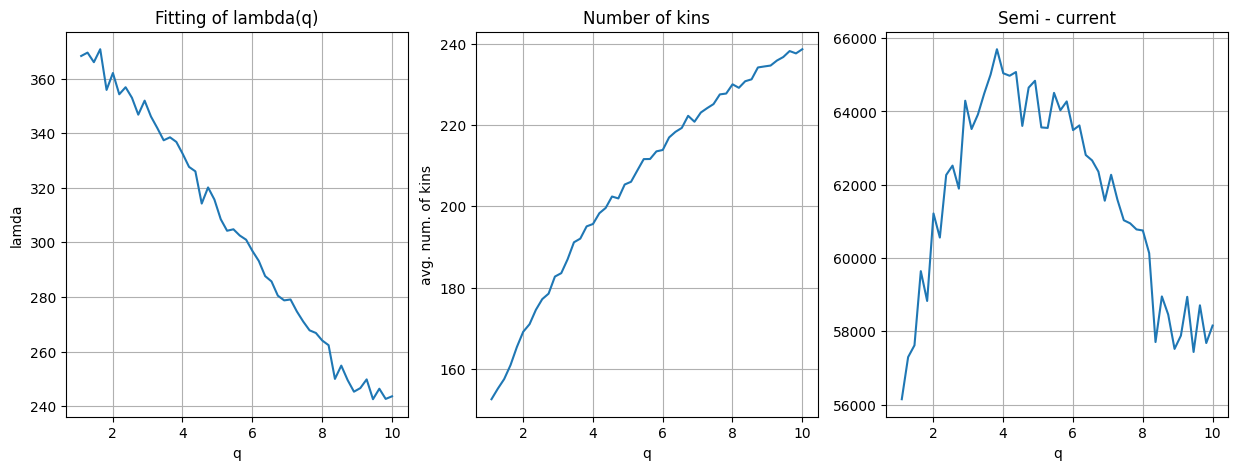

In [24]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(15,5))

ax1.plot(Q, lamda)
ax1.set(xlabel = "q", ylabel = "lamda", title = "Fitting of lambda(q)")
ax1.grid()

ax2.plot(Q, num_kins)
ax2.set(xlabel = "q", ylabel = "avg. num. of kins", title = "Number of kins")
ax2.grid()


ax3.plot(Q, num_kins*lamda)
ax3.set(xlabel = "q", ylabel = "", title = "Semi - current")
ax3.grid()

In [25]:
fig.savefig("current_5.png" ,dpi=300)

In [2]:
import binding

ModuleNotFoundError: No module named 'binding'